# EDA — Canton-Level Crime Risk Index (Ecuador)

**Notebook purpose:** Build and justify a cantonal crime risk index that is robust and academically defensible, and produce inputs ready for the forecasting stage.

**Research questions:**
1. How consistent is a shrinkage-adjusted rate-based index compared to raw counts and unadjusted rates?
2. How can we segment cantons into structural risk profiles without strong arbitrariness in `k`?
3. What methodological decisions carry over to the forecasting notebook?

**Design summary:**
- Standardization and unification of sources by canton–province–year–month.
- Construction of rates per 10k inhabitants and derivation of PCA-based weights (PC1).
- Composite z-score index (no fixed threshold bands).
- Structural segmentation with KMeans; `k` selected by consensus of multiple metrics.
- Robustness validation: comparison against raw count index and unadjusted rate index.

## Notebook Structure

| Section | Contents |
|---|---|
| **1. Data Sources** | Data loading, quick column audit and quality check |
| **2. Cleaning** | Key normalization, date extraction, monthly merge with population |
| **3. Index** | Rates per 10k → Bayesian shrinkage → PCA → weighted z-score (`indice_riesgo`) |
| **4. KMeans** | Multi-metric evaluation (Elbow + Silhouette + CH + DB), k selection, cluster assignment |
| **5. Visualizations** | Distributions, correlations, temporal evolution, canton profiles |
| **6. Robustness** | Comparison: shrunk vs. raw rates vs. absolute counts |

**Questions answered by this notebook:**
1. How consistent is the shrinkage index versus raw rates and absolute counts?
2. What is the optimal number of clusters by consensus of metrics?
3. What methodological decisions carry over to the forecasting notebook?

In [26]:
import pandas as pd
import os

# ── Global parameters ─────────────────────────────────
TASA_BASE = 10000   # rate base (inhabitants): change here to use /10k, /100k, etc.

# ── Load data sources ─────────────────────────────────
files = {
    'homicidios'     : 'data/homicidios 2014-2026.xlsx',
    'armas'          : 'data/armas ilicitas 2017-2026.xlsx',
    'arrestos'       : 'data/detenidos 2019 - 2026.xlsx',
    'poblacion_anual': 'data/poblacion_cantones_2019-2025.csv',
}

dfs = {}
for name, path in files.items():
    ext = os.path.splitext(path)[-1]
    if ext == '.xlsx' and name != 'homicidios':
        dfs[name] = pd.read_excel(path, sheet_name=1)
    elif ext == '.csv':
        dfs[name] = pd.read_csv(path, sep=';' if name == 'poblacion_anual' else ',')
    else:
        dfs[name] = pd.read_excel(path)

# ── Quick audit ───────────────────────────────────────
for name, df in dfs.items():
    print(f'\n─── {name} ───')
    print(f'  Shape  : {df.shape}')
    print(f'  Columns: {list(df.columns)}')
    print(f'  Nulls  : {df.isnull().sum().sum()}')
    print(df.head(2))



─── homicidios ───
  Shape  : (41221, 33)
  Columns: ['tipo_muerte', 'zona', 'subzona', 'distrito', 'circuito', 'codigo_subcircuito', 'subcircuito', 'codigo_provincia', 'provincia', 'codigo_canton', 'canton', 'coordenada_y', 'coordenada_x', 'area_hecho', 'lugar', 'tipo_lugar', 'fecha_infraccion', 'hora_infraccion', 'arma', 'tipo_arma', 'presunta_motivacion', 'presun_motiva_observada', 'probable_causa_motivada', 'edad', 'medida_edad', 'sexo', 'genero', 'etnia', 'estado_civil', 'nacionalidad', 'discapacidad', 'profesion_registro_civil', 'instruccion']
  Nulls  : 1
  tipo_muerte    zona         subzona          distrito         circuito  \
0   FEMICIDIO  ZONA 9      D.M. QUITO          QUITUMBE        TURUBAMBA   
1   ASESINATO  ZONA 8  D.M. GUAYAQUIL  NUEVA PROSPERINA  NUEVO GUAYAQUIL   

  codigo_subcircuito        subcircuito  codigo_provincia  provincia  \
0        17D07C05S06        TURUBAMBA 6                17  PICHINCHA   
1        09D08C06S01  NUEVO GUAYAQUIL 1                 9

## 1. Data Sources and Coverage

| Source | Period | Granularity |
|---|---|---|
| `homicidios` | 2014–2026 | Event per victim |
| `armas` | 2017–2025 | Seizure event |
| `arrestos` | 2019–2025 | Event per detainee |
| `poblacion_anual` | 2019–2025 | Annual canton-level population estimate |

The loading cell above also performs a quick quality and column consistency audit before merging sources.

## 2. Cleaning and Unification of the Monthly Dataset

In [27]:
import unicodedata
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Canton/province name cleaning function ────────────
def clean_canton(s):
    s = str(s).strip().upper()
    s = unicodedata.normalize('NFKD', s)
    s = s.encode('ascii', 'ignore').decode()
    s = ' '.join(s.split())          # collapse multiple spaces
    return s

# ── Extract year and month from each source ───────────
for src, col_fecha in [
    ('homicidios', 'fecha_infraccion'),
    ('armas',      'fecha_evento'),
    ('arrestos',   'fecha_detencion_aprehension'),
]:
    dt = pd.to_datetime(dfs[src][col_fecha], errors='coerce')
    dfs[src]['anio'] = dt.dt.year
    dfs[src]['mes']  = dt.dt.month

# ── Normalize canton and province keys ───────────────
dfs['homicidios']['canton_key']    = dfs['homicidios']['canton'].apply(clean_canton)
dfs['homicidios']['provincia_key'] = dfs['homicidios']['provincia'].apply(clean_canton)
dfs['armas']['canton_key']         = dfs['armas']['nombre_canton'].apply(clean_canton)
dfs['armas']['provincia_key']      = dfs['armas']['nombre_provincia'].apply(clean_canton)
dfs['arrestos']['canton_key']      = dfs['arrestos']['nombre_canton'].apply(clean_canton)
dfs['arrestos']['provincia_key']   = dfs['arrestos']['nombre_provincia'].apply(clean_canton)

print("Standardization complete")
for name in ['homicidios', 'armas', 'arrestos']:
    df  = dfs[name]
    yrs = sorted(df['anio'].dropna().unique().astype(int).tolist())
    print(f"  {name:<22}: shape={df.shape}  |  years {yrs[0]}–{yrs[-1]}")


Standardization complete
  homicidios            : shape=(41221, 37)  |  years 2014–2026
  armas                 : shape=(72555, 32)  |  years 2017–2026
  arrestos              : shape=(571910, 39)  |  years 2019–2026


In [28]:
from functools import reduce

KEY = ['canton_key', 'provincia_key', 'anio', 'mes']

# Homicides: 1 row = 1 victim
hom = (dfs['homicidios']
       .dropna(subset=['canton_key', 'anio', 'mes'])
       .groupby(KEY).size()
       .reset_index(name='homicidios'))

# Weapons: seizure incidents
armas_agg = (dfs['armas']
             .dropna(subset=['canton_key', 'anio', 'mes'])
             .groupby(KEY).size()
             .reset_index(name='armas_incautadas'))

# Arrests: detainees
arr = (dfs['arrestos']
       .dropna(subset=['canton_key', 'anio', 'mes'])
       .groupby(KEY).size()
       .reset_index(name='arrestos'))

# ── Outer merge of the 3 sources ──────────────────────
master = reduce(lambda l, r: l.merge(r, on=KEY, how='outer'),
                [hom, armas_agg, arr])
master['anio'] = master['anio'].astype('Int64')
master['mes']  = master['mes'].astype('Int64')

# ── Merge annual population (2019-2025) ───────────────────────────────────
# Using canton_key + provincia_key + anio avoids collisions for
# homonymous cantons (e.g. OLMEDO in LOJA and in MANABI) and assigns
# the actual population for the corresponding year instead of a fixed census.
CANTON_NORM = {
    'DISTRITO METROPOLITANO DE QUITO': 'QUITO',
}
PROV_NORM = {
    'SANTO DOMINGO DE LOS TSACHILAS': 'STO DGO DE LOS TSACHILAS',
}

pop_long = dfs['poblacion_anual'].melt(
    id_vars=['Provincia', 'Cantón'],
    value_vars=[str(y) for y in range(2019, 2026)],
    var_name='anio',
    value_name='poblacion')
pop_long['anio'] = pop_long['anio'].astype(int)
pop_long['canton_key']    = pop_long['Cantón'].apply(clean_canton).replace(CANTON_NORM)
pop_long['provincia_key'] = pop_long['Provincia'].apply(clean_canton).replace(PROV_NORM)

master = master.merge(
    pop_long[['canton_key', 'provincia_key', 'anio', 'poblacion']],
    on=['canton_key', 'provincia_key', 'anio'],
    how='left'
)

sin_pop = (master[master['anio'].isin(range(2019, 2026))]
           .loc[lambda d: d['poblacion'].isna(), 'canton_key'].unique())
ignorar = {'MAR TERRITORIAL', 'SIN_DATO'}
real_sin_pop = [c for c in sin_pop if c not in ignorar]
if real_sin_pop:
    print(f"⚠  Cantons without population data (2019-2025): {real_sin_pop}")
else:
    print("✓ All cantons (2019-2025) matched with annual population")

print(f"Monthly dataset: {master.shape}")
print(f"Unique cantons : {master.canton_key.nunique()}")
anio_min = int(master['anio'].min()); mes_min = int(master['mes'].min())
anio_max = int(master['anio'].max()); mes_max = int(master['mes'].max())
print(f"Range: {anio_min}/{mes_min:02d} – {anio_max}/{mes_max:02d}")
print(f"\nNull percentage by column (%):")
print((master.isnull().mean() * 100).round(1).to_string())
master.head()


✓ All cantons (2019-2025) matched with annual population
Monthly dataset: (21363, 8)
Unique cantons : 221
Range: 2014/01 – 2026/12

Null percentage by column (%):
canton_key          0.00
provincia_key       0.00
anio                0.00
mes                 0.00
homicidios         60.60
armas_incautadas   46.40
arrestos           18.90
poblacion          20.20


,canton_key,provincia_key,anio,mes,homicidios,armas_incautadas,arrestos,poblacion
0,24 DE MAYO,MANABI,2014,3,1.00,NaN,NaN,NaN
1,24 DE MAYO,MANABI,2015,2,1.00,NaN,NaN,NaN
2,24 DE MAYO,MANABI,2015,12,1.00,NaN,NaN,NaN
3,24 DE MAYO,MANABI,2016,3,1.00,NaN,NaN,NaN
4,24 DE MAYO,MANABI,2017,1,2.00,4.00,NaN,NaN


## 3. Crime Risk Index Construction

**Pipeline:**
1. Aggregate events by canton × year (2019–2025)
2. **Rates per 10k inhabitants**: $r_i = (x_i / \text{pop}) \times 10{,}000$
3. **Bayesian shrinkage** on rates: $\hat{r}_i = w_i r_i + (1-w_i)\bar{r}$
4. **PCA** on smoothed rates → empirical weights from PC1
5. **Z-score** per indicator + weighted combination → `indice_riesgo`

| Advantage | Limitation |
|---|---|
| Small and large cantons are comparable | Sensitive to very small cantons (shrinkage mitigates this) |
| Captures per capita risk | Requires reliable population data |
| Empirically derived weights (PCA), not subjective | Clusters depend on the structure of the analyzed period |

### Key Concepts

- **Rate per 10k**: events adjusted by population to make cantons comparable.
- **Standardization (z-score)**: puts all indicators on the same scale (mean 0, std 1).
- **PCA**: technique that summarizes shared information among correlated variables.
- **Weights from PC1 loadings**: empirical way to weight indicators without subjective manual assignment.

Core idea: reduce arbitrariness and maintain territorial comparability.

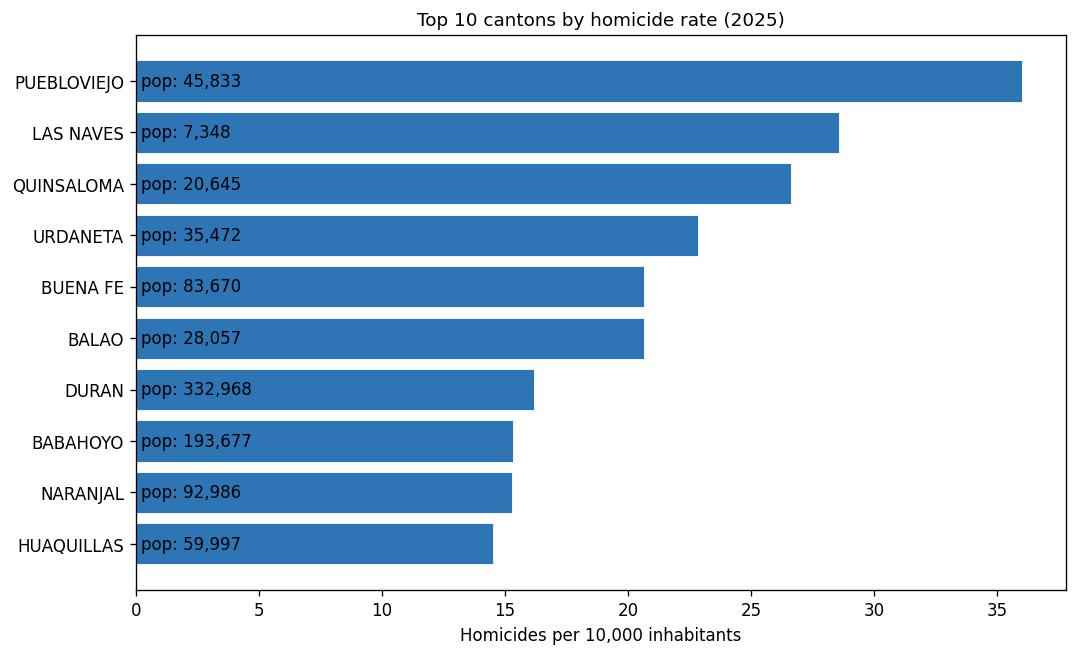

In [29]:
from matplotlib import axes
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

INDICADORES = ['homicidios', 'armas_incautadas', 'arrestos']
ANIOS_COMP  = list(range(2019, 2026))

# ── 1. Annual aggregation by canton ────────────────────────────────────────
master_annual = (
    master[master['anio'].isin(ANIOS_COMP)]
    .groupby(['canton_key', 'provincia_key', 'anio'], as_index=False)
    .agg(
        homicidios       =('homicidios',       'sum'),
        armas_incautadas =('armas_incautadas', 'sum'),
        arrestos         =('arrestos',         'sum'),
        poblacion        =('poblacion',        'first'),
    )
).reset_index(drop=True)

master_annual[INDICADORES] = master_annual[INDICADORES].fillna(0)

# ── 2. Rates per TASA_BASE inhabitants ─────────────────────────────────────
for col in INDICADORES:
    master_annual[f'{col}_r1k'] = (
        master_annual[col] / master_annual['poblacion'] * TASA_BASE
    )

RATES        = [f'{c}_r1k' for c in INDICADORES]
RATES_LABELS = ['Homicides/10k', 'Weapons/10k', 'Arrests/10k']

ANIO_DIAG  = 2025
UMBRAL_POP = 10000   # population threshold to define "small canton"

df_diag   = master_annual[master_annual['anio'] == ANIO_DIAG].copy()
mask_peq  = df_diag['poblacion'] < UMBRAL_POP
df_diag['cuartil_pop'] = pd.qcut(
    df_diag['poblacion'], q=4,
    labels=['Q1 (smallest)', 'Q2', 'Q3', 'Q4 (largest)'])

COL = '#2E75B6'

# Top 10 by homicide rate with population annotation
plt.figure(figsize=(10, 6))
top15_t = (df_diag
           .nlargest(10, 'homicidios_r1k')[['canton_key', 'poblacion', 'homicidios_r1k']]
           .sort_values('homicidios_r1k'))
bcolors = [COL for _ in top15_t['poblacion']]
plt.barh(top15_t['canton_key'], top15_t['homicidios_r1k'],
         color=bcolors, edgecolor='white', linewidth=0.5)
for i, (_, row) in enumerate(top15_t.iterrows()):
    plt.text(0.2, i, f"pop: {row['poblacion']:,.0f}", fontsize=10, va='center')
plt.xlabel('Homicides per 10,000 inhabitants')
plt.title(f'Top 10 cantons by homicide rate ({ANIO_DIAG})', fontsize=11)

plt.show()


## Bayesian Shrinkage Correction

### What is it?

*Bayesian shrinkage* (a James-Stein estimator applied to rates) **contracts** estimates from small groups toward a global reference value. In Bayesian terms, it is equivalent to assigning a *prior* that each canton resembles the national average, and then updating it with observed data.

### Formulation

$$\hat{r}_i = w_i \cdot r_i + (1 - w_i) \cdot \bar{r}$$

where:
- $r_i$ = observed rate in canton $i$
- $\bar{r}$ = national reference rate (period mean)
- $w_i = \dfrac{n_i}{n_i + m}$ = weight proportional to population
- $m$ = shrinkage parameter (median population of the dataset)

### Behavior by Canton Size

| Canton | Population | $w_i$ | Effect on the rate |
|---|---|---|---|
| Large (Guayaquil, Quito) | $\gg m$ | $\approx 1$ | No appreciable change |
| Medium | $\approx m$ | $\approx 0.5$ | Halfway between observed and mean |
| Small (rural) | $\ll m$ | $\approx 0$ | Pulled toward the national mean |

### Why is it appropriate here?

1. Ecuador has ~224 cantons with highly heterogeneous populations (from ~800 to ~2.8M inhabitants).
2. Without correction, the index would amplify statistical noise as if it were a real security signal.
3. The median population as $m$ is **interpretable and non-arbitrary**: it represents the population of a "typical" canton.
4. The correction is proportional — it does not exclude cantons, it only reduces their influence when data is scarce.
5. It is conceptually equivalent to Bayesian smoothing used in *small-area estimation* in demography and epidemiology.

**Smoothed rates (`_r1k_shrunk`) replace raw rates (`_r1k`) as the baseline for all downstream pipeline steps. Original rates are preserved in `_r1k_raw` for diagnostics and robustness checks.**

In [30]:

# ═══════════════════════════════════════════════════════════════════════════
# Bayesian Shrinkage on rates per 10k inhabitants
#   r̂_i = w_i · r_i + (1 − w_i) · r̄
#   w_i  = pop_i / (pop_i + m)     m = median population of the dataset
# Large cantons keep their rate; small ones are pulled toward the mean.
# ═══════════════════════════════════════════════════════════════════════════

m_shrink = master_annual['poblacion'].median()

for col in INDICADORES:
    rate_col = f'{col}_r1k'
    raw_col  = f'{col}_r1k_raw'
    shr_col  = f'{col}_r1k_shrunk'

    # Preserve original rate before modification
    master_annual[raw_col] = master_annual[rate_col].copy()

    # Global reference rate (mean of the full period)
    global_rate = master_annual[rate_col].mean()

    # Bayesian weight: ~0 for small cantons, ~1 for large cantons
    w_pop = master_annual['poblacion'] / (master_annual['poblacion'] + m_shrink)

    # Smoothed rate
    master_annual[shr_col] = (
        w_pop * master_annual[rate_col] + (1 - w_pop) * global_rate
    )

    # Overwrite _r1k: all downstream pipeline uses this column
    master_annual[rate_col] = master_annual[shr_col]

# ── Re-fit PCA and weights on smoothed rates ────────────────────────────────
X_shr = StandardScaler().fit_transform(master_annual[RATES].fillna(0))
pca   = PCA(n_components=len(RATES))
X_pca = pca.fit_transform(X_shr)

if pca.components_[0].mean() < 0:
    pca.components_[0] *= -1
    X_pca[:, 0]        *= -1

loadings_pc1 = np.abs(pca.components_[0])
PESOS        = (loadings_pc1 / loadings_pc1.sum()).tolist()

# Update PC1 in master_annual for visualizations and clustering
master_annual['pc1_index'] = X_pca[:, 0]

print(f"Shrinkage applied — parameter m = {m_shrink:,.0f} (median population)")
print()
print(f"PCA re-fitted on smoothed rates:")
print(f"  PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
for lbl, w, load in zip(RATES_LABELS, PESOS, pca.components_[0]):
    print(f"  {lbl:<22}: weight = {w:.4f}  (PC1 loading = {load:+.4f})")
print()

# Magnitude of adjustment per indicator
for col in INDICADORES:
    delta  = (master_annual[f'{col}_r1k'] - master_annual[f'{col}_r1k_raw']).abs()
    pct    = (delta > 0.01).mean() * 100
    maxdlt = delta.max()
    print(f"  {col:<22}: {pct:.0f}% of records adjusted > 0.01  |  max Δ = {maxdlt:.2f}")
print("\n→ Large cantons remain practically unchanged.")
print("→ Rates for small cantons are pulled toward the national mean.")


Shrinkage applied — parameter m = 27,048 (median population)

PCA re-fitted on smoothed rates:
  PC1 explains 51.7% of variance
  Homicides/10k         : weight = 0.4683  (PC1 loading = +0.6995)
  Weapons/10k           : weight = 0.4750  (PC1 loading = +0.7095)
  Arrests/10k           : weight = 0.0567  (PC1 loading = +0.0848)

  homicidios            : 98% of records adjusted > 0.01  |  max Δ = 20.92
  armas_incautadas      : 99% of records adjusted > 0.01  |  max Δ = 40.23
  arrestos              : 99% of records adjusted > 0.01  |  max Δ = 185.00

→ Large cantons remain practically unchanged.
→ Rates for small cantons are pulled toward the national mean.


### 3b. PCA on Smoothed Rates → Empirical Weights

The latent structure of the post-shrinkage rates is visualized here to justify the empirical weights of the composite index.

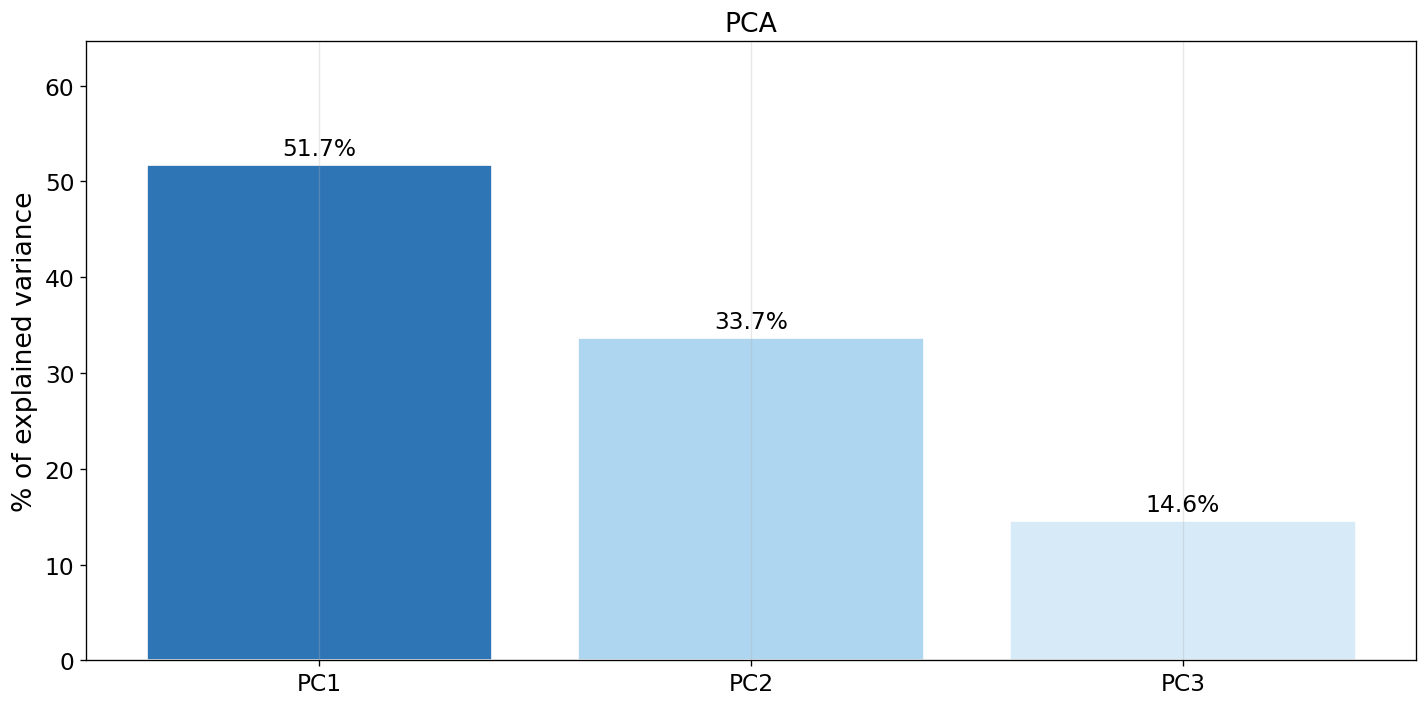

PCA previo finalizado: usar PC1 para derivar pesos antes de construir el índice z-score.


In [31]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))

# ── Scree plot ─────────────────────────────────────────────────────────────
ev = pca.explained_variance_ratio_ * 100
bars_s = plt.bar([f'PC{i+1}' for i in range(len(ev))], ev,
                 color=['#2E75B6', '#AED6F1', '#D6EAF8'],
                      edgecolor='white')
plt.bar_label(bars_s, fmt='%.1f%%', padding=3, fontsize=14)
plt.title('PCA', fontsize=16)
plt.ylabel('% of explained variance', fontsize=16)
plt.ylim(0, ev.max() * 1.25)
# Increase font size of y-ticks and x-ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Increase size of the bar labels
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()

plt.savefig('plots/pca_pre_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

print('PCA previo finalizado: usar PC1 para derivar pesos antes de construir el índice z-score.')

### 3c. Weighted Z-Score Index

Using the weights derived from PC1 loadings, the composite index is built over the z-scores of the smoothed rates per 10k.

In [32]:
# ── 4. Global z-score (mu and sigma of the full period) ──────────────────
for col in RATES:
    mu  = master_annual[col].mean()
    sig = master_annual[col].std()
    master_annual[f'{col}_z'] = (master_annual[col] - mu) / sig

# Z-score columns used in the index and clustering
Z_COLS = [f'{col}_z' for col in RATES]

# ── 5. Weighted composite index (weights derived from PCA) ────────────────
master_annual['indice_riesgo'] = sum(
    master_annual[z] * w for z, w in zip(Z_COLS, PESOS)
)

# PC1 as alternative index (for cross-validation)
master_annual['pc1_index'] = X_pca[:, 0]

# Composite canton_id to separate homonymous cantons in different provinces
master_annual['canton_id'] = (
    master_annual['provincia_key'].astype(str) + ' | ' + master_annual['canton_key'].astype(str)
)

print('Index built (rates with shrinkage + PCA weights + z-score).')
print(f"  Cantons × years  : {len(master_annual):,}")
print(f"  indice_riesgo    → mean = {master_annual['indice_riesgo'].mean():.3f} | "
      f"std = {master_annual['indice_riesgo'].std():.3f}")


Index built (rates with shrinkage + PCA weights + z-score).
  Cantons × years  : 1,553
  indice_riesgo    → mean = 0.000 | std = 0.832


## 4. KMeans Segmentation

PCA showed that the three indicators share a common latent factor (PC1). Cantons are segmented into homogeneous risk clusters using KMeans on their **average 2019–2025 profile** (z-scores of shrinkage-adjusted rates per 10k).

**Pipeline:**
1. Feature matrix: 2019–2025 mean z-score rates per canton
2. Multi-metric evaluation: Elbow + Silhouette + Calinski-Harabasz + Davies-Bouldin
3. k selection by consensus of metrics
4. KMeans with optimal k
5. Coherence diagnostic against index quartiles
6. Visualization: PCA space colored by cluster

### KMeans Explained

`KMeans` groups cantons with similar risk profiles. It uses no prior labels — it learns the groups purely from the data.

**What does `k` mean?**
- It is the number of groups to form.
- It is evaluated with internal metrics (Silhouette, Calinski-Harabasz, Davies-Bouldin) to avoid arbitrary selection.

**Practical interpretation:**
- Clusters do not replace the index; they complement it.
- They are useful for segmenting public policy strategies by territorial risk profile.

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

# ── Average profile per canton (2019–2025) ────────────────────────────────
perfil_canton = (
    master_annual
    .groupby(['canton_id', 'provincia_key', 'canton_key'], as_index=False)[Z_COLS]
    .mean()
)
perfil_canton[Z_COLS] = perfil_canton[Z_COLS].fillna(0)
X_km = perfil_canton[Z_COLS].values

# ── Multi-metric evaluation for k selection ───────────────────────────────
k_range = range(2, 11)
rows = []
for k in k_range:
    km  = KMeans(n_clusters=k, n_init=30, random_state=42)
    lbl = km.fit_predict(X_km)
    rows.append({
        'k'                 : k,
        'Inertia'           : km.inertia_,
        'Silhouette'        : silhouette_score(X_km, lbl),
        'Calinski_Harabasz' : calinski_harabasz_score(X_km, lbl),
        'Davies_Bouldin'    : davies_bouldin_score(X_km, lbl),
    })

k_metrics = pd.DataFrame(rows)
k_metrics['rank_sil']   = k_metrics['Silhouette'].rank(ascending=False, method='min')
k_metrics['rank_ch']    = k_metrics['Calinski_Harabasz'].rank(ascending=False, method='min')
k_metrics['rank_db']    = k_metrics['Davies_Bouldin'].rank(ascending=True,  method='min')
k_metrics['rank_total'] = k_metrics[['rank_sil', 'rank_ch', 'rank_db']].mean(axis=1)

best_k = int(
    k_metrics.sort_values(['rank_total', 'Silhouette'], ascending=[True, False])
    .iloc[0]['k']
)
K_OPT = int(best_k)

print('k selection by consensus (Silhouette + Calinski-Harabasz + Davies-Bouldin):')
print(
    k_metrics[['k', 'Silhouette', 'Calinski_Harabasz', 'Davies_Bouldin', 'rank_total']]
    .sort_values('rank_total')
    .round(4)
    .to_string(index=False)
)
print(f"\nRecommended k by consensus: {K_OPT}")


k selection by consensus (Silhouette + Calinski-Harabasz + Davies-Bouldin):
 k  Silhouette  Calinski_Harabasz  Davies_Bouldin  rank_total
 3        0.44             129.64            0.88        1.33
 5        0.37             126.00            0.91        2.67
 4        0.37             123.01            0.98        3.33
 6        0.35             116.21            0.98        4.67
 9        0.31             112.24            0.97        5.33
 2        0.49             110.08            1.18        5.67
 7        0.33             111.82            1.04        6.33
10        0.31             109.93            1.00        7.00
 8        0.30             109.90            1.06        8.67

Recommended k by consensus: 3


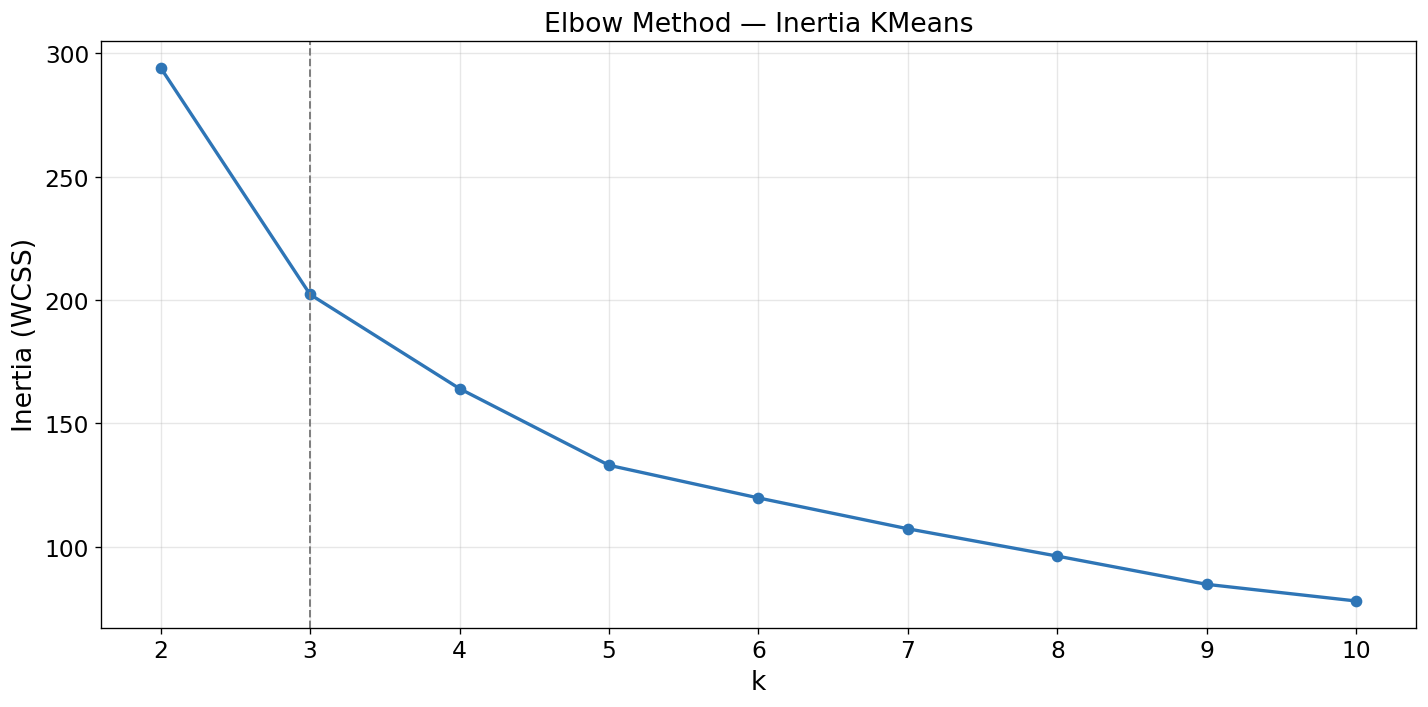

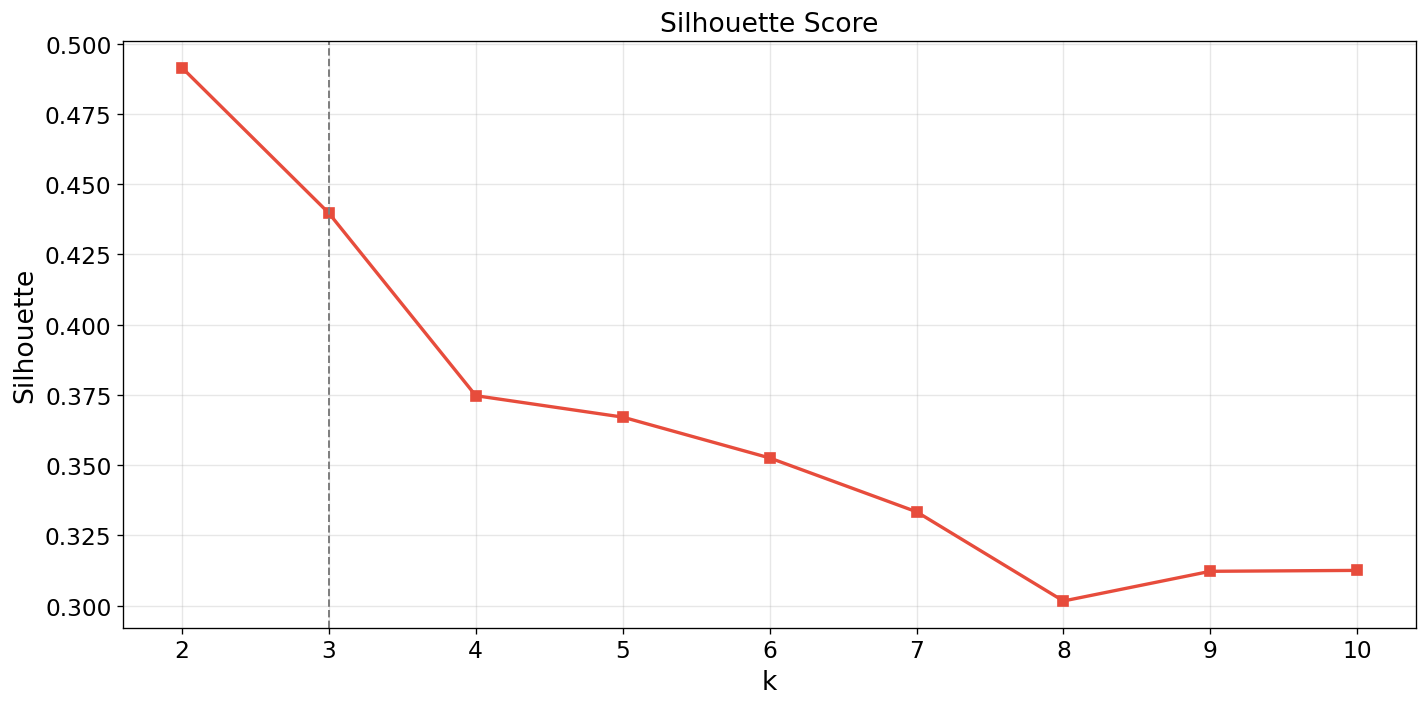

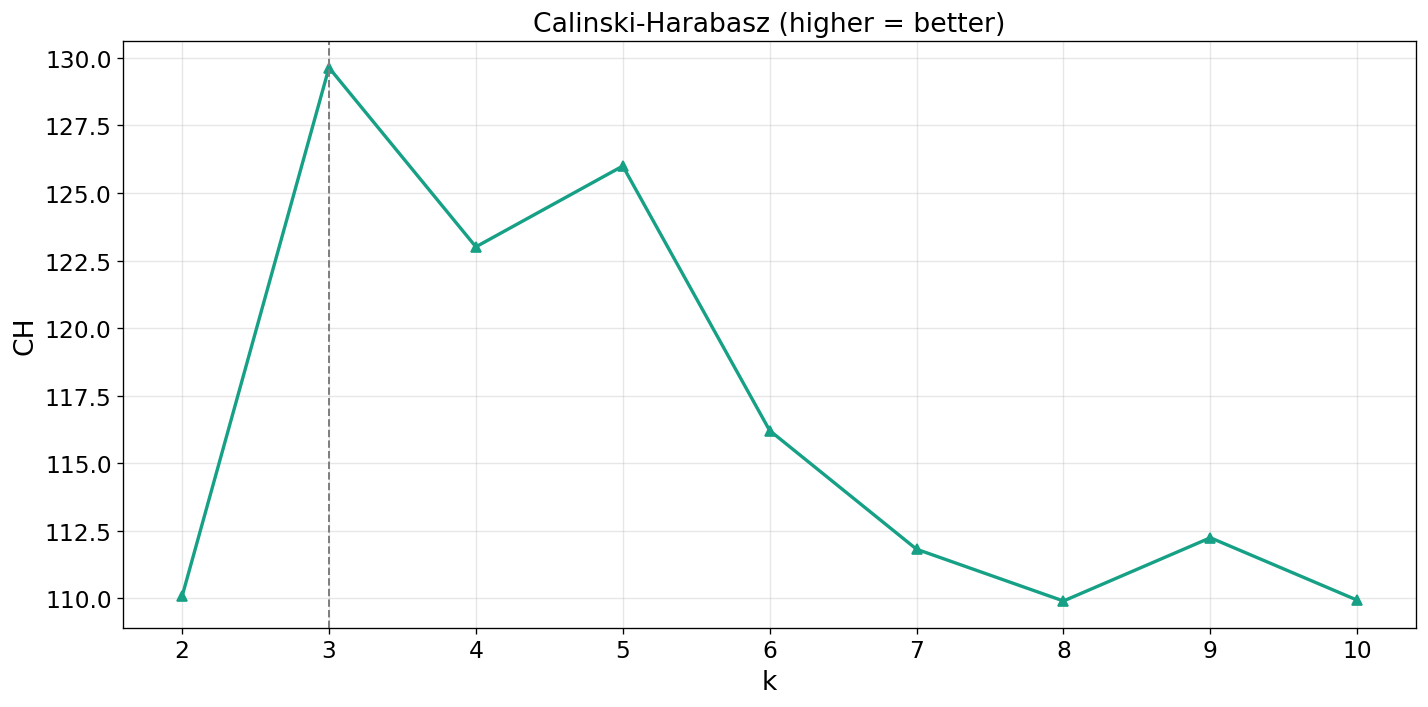

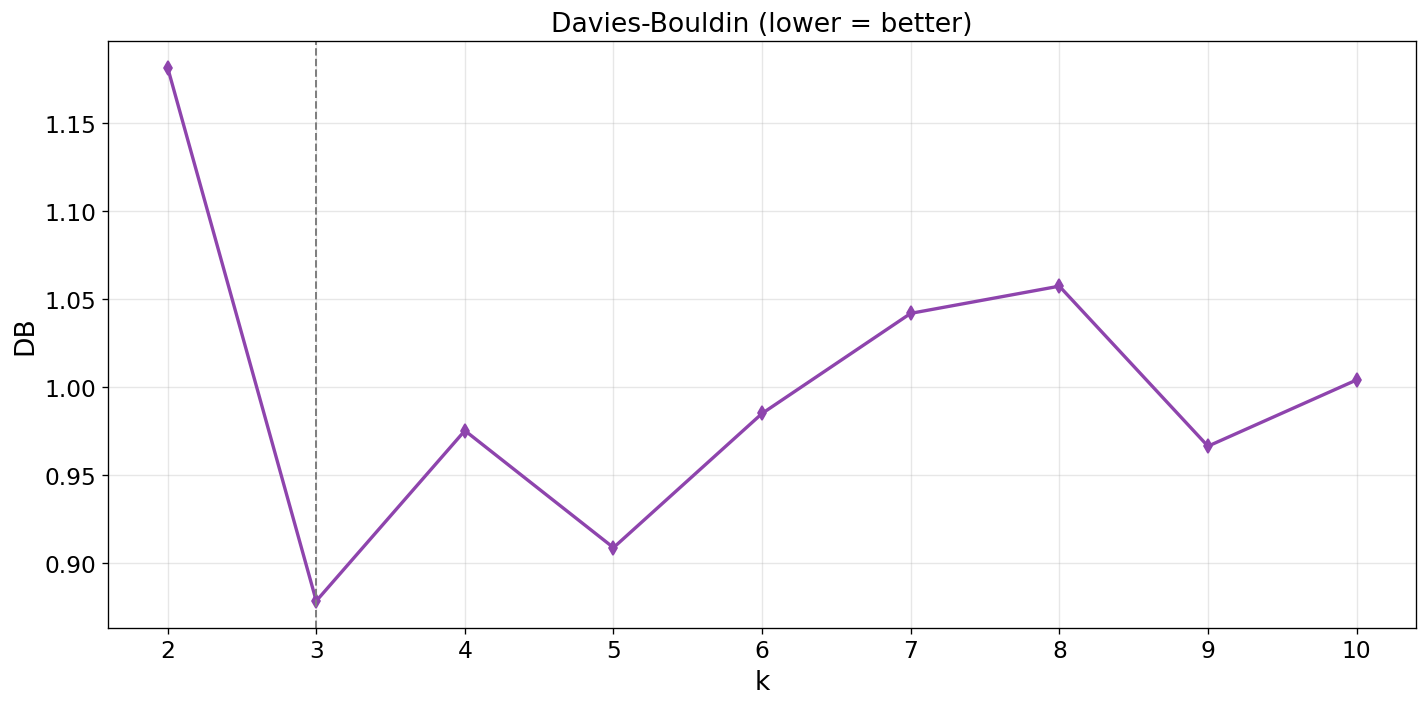

In [34]:
# ── Diagnóstico visual de selección de k ──────────────────────────────────
plt.figure(figsize=(12, 6))

plt.plot(k_metrics['k'], k_metrics['Inertia'], marker='o', color='#2E75B6', linewidth=2)
plt.axvline(K_OPT, color='gray', linestyle='--', linewidth=1.2)
plt.title('Elbow Method — Inertia KMeans', fontsize=16)
plt.xlabel('k', fontsize=16)
plt.ylabel('Inertia (WCSS)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/kmeans_k_selection_inertia.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(k_metrics['k'], k_metrics['Silhouette'], marker='s', color='#E74C3C', linewidth=2)
plt.axvline(K_OPT, color='gray', linestyle='--', linewidth=1.2)
plt.title('Silhouette Score', fontsize=16)
plt.xlabel('k', fontsize=16)
plt.ylabel('Silhouette', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/kmeans_k_selection_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(k_metrics['k'], k_metrics['Calinski_Harabasz'], marker='^', color='#16A085', linewidth=2)
plt.axvline(K_OPT, color='gray', linestyle='--', linewidth=1.2)
plt.title('Calinski-Harabasz (higher = better)', fontsize=16)
plt.xlabel('k', fontsize=16)
plt.ylabel('CH', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/kmeans_k_selection_calinski.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(k_metrics['k'], k_metrics['Davies_Bouldin'], marker='d', color='#8E44AD', linewidth=2)
plt.axvline(K_OPT, color='gray', linestyle='--', linewidth=1.2)
plt.title('Davies-Bouldin (lower = better)', fontsize=16)
plt.xlabel('k', fontsize=16)
plt.ylabel('DB', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/kmeans_k_selection_davies_bouldin.png', dpi=150, bbox_inches='tight')
plt.show()


In [35]:
# ── KMeans with optimal k ──────────────────────────────────────────────────
km_final = KMeans(n_clusters=K_OPT, n_init=80, random_state=42)
perfil_canton['cluster'] = km_final.fit_predict(X_km)

# Order clusters by mean PC1 (low → high risk)
pc1_por_canton = (
    master_annual.groupby('canton_id')['pc1_index']
    .mean()
    .reset_index(name='pc1_mean')
)
perfil_canton = perfil_canton.merge(pc1_por_canton, on='canton_id', how='left')

orden_clusters = (
    perfil_canton.groupby('cluster')['pc1_mean']
    .mean()
    .sort_values()
    .index.tolist()
)

CLUSTER_ORDER     = ['Low', 'Medium', 'High', 'Very High', 'Critical', 'Extreme'][:K_OPT]
cluster_label_map = {c: CLUSTER_ORDER[i] for i, c in enumerate(orden_clusters)}
perfil_canton['cluster_label'] = perfil_canton['cluster'].map(cluster_label_map)

master_annual = (
    master_annual
    .drop(columns=['cluster', 'cluster_label'], errors='ignore')
    .merge(perfil_canton[['canton_id', 'cluster', 'cluster_label']], on='canton_id', how='left')
)

PALETTE_KM        = plt.cm.tab10.colors[:K_OPT]
CLUSTER_COLOR_MAP = dict(zip(CLUSTER_ORDER, PALETTE_KM))

print(f"KMeans complete with k = {K_OPT}")
print('Cantons per cluster:')
for lbl in CLUSTER_ORDER:
    n = (perfil_canton['cluster_label'] == lbl).sum()
    print(f"  {lbl:<12}: {n}")


KMeans complete with k = 3
Cantons per cluster:
  Low         : 29
  Medium      : 157
  High        : 37


In [36]:
# ── Internal coherence diagnostic for clusters ────────────────────────────

# Cross-tab: clusters vs index quartiles
master_annual['indice_q4'] = pd.qcut(
    master_annual['indice_riesgo'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4'],
    duplicates='drop',
)
print('Cross-tab: KMeans cluster vs index quartiles (Q1-Q4):')
crosstab = pd.crosstab(
    master_annual['cluster_label'],
    master_annual['indice_q4'],
    margins=True,
    dropna=False,
).reindex(index=CLUSTER_ORDER + ['All'], fill_value=0)
print(crosstab.to_string())

# Centroid summary
print('\nCentroids (z-scores of rates per 10k):')
centroides = (
    perfil_canton.groupby('cluster_label')[Z_COLS]
    .mean()
    .rename(columns=dict(zip(Z_COLS, RATES_LABELS)))
    .reindex(CLUSTER_ORDER)
)
print(centroides.round(3).to_string())

print('\nCantons per cluster:')
for lbl in CLUSTER_ORDER:
    n = (perfil_canton['cluster_label'] == lbl).sum()
    print(f'  {lbl:<12}: {n}')


Cross-tab: KMeans cluster vs index quartiles (Q1-Q4):
indice_q4       Q1   Q2   Q3   Q4   All
cluster_label                          
Low             87   50   49   17   203
Medium         296  323  296  168  1091
High             4   13   41  201   259
All            387  386  386  386  1553

Centroids (z-scores of rates per 10k):
               Homicides/10k  Weapons/10k  Arrests/10k
cluster_label                                         
Low                    -0.41        -0.56         1.56
Medium                 -0.18        -0.22        -0.38
High                    1.07         1.39         0.37

Cantons per cluster:
  Low         : 29
  Medium      : 157
  High        : 37


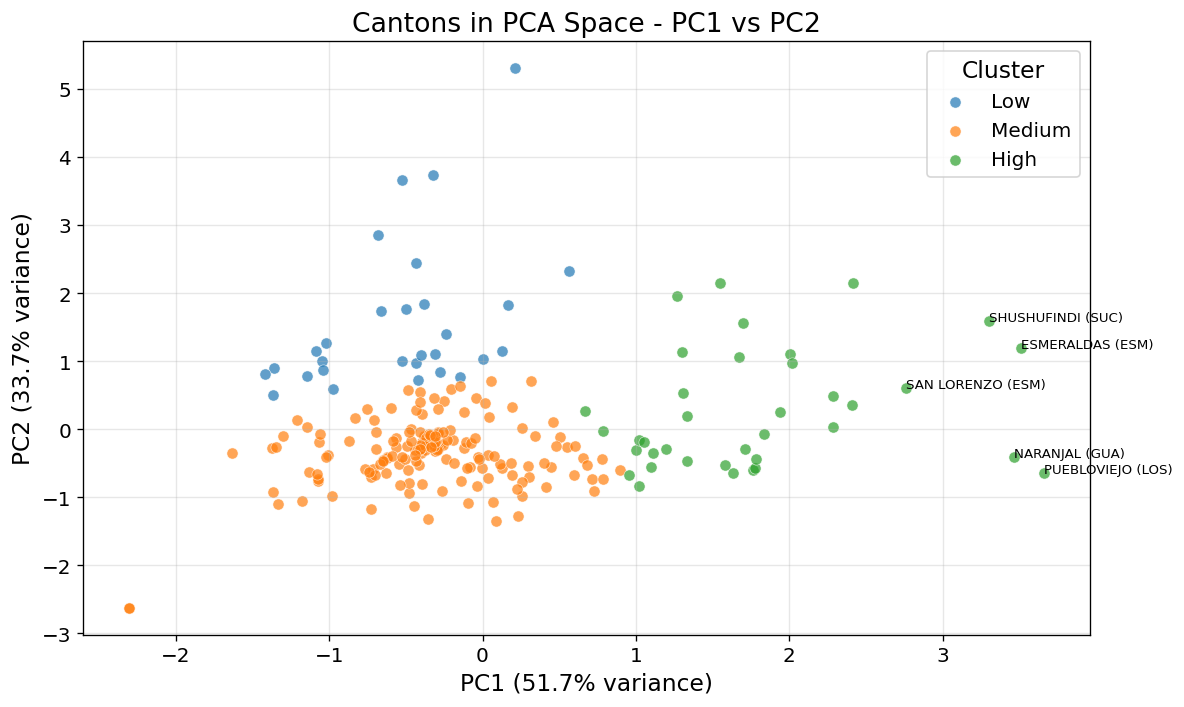

In [37]:

# ── Cantones en espacio PCA coloreados por cluster ────────────────────────
import seaborn as sns

X_all     = StandardScaler().fit_transform(master_annual[RATES].fillna(0))
X_pca_all = pca.transform(X_all)

pc_space = master_annual[['canton_id', 'canton_key', 'provincia_key',
                           'cluster_label', 'indice_riesgo']].copy()
pc_space['pc1'] = X_pca_all[:, 0]
pc_space['pc2'] = X_pca_all[:, 1]
pc_space['pc3'] = X_pca_all[:, 2]

pc_canton = (
    pc_space
    .groupby(['canton_id', 'canton_key', 'provincia_key', 'cluster_label'], as_index=False)
    .agg(pc1=('pc1', 'mean'), pc2=('pc2', 'mean'), pc3=('pc3', 'mean'),
         indice_riesgo=('indice_riesgo', 'mean'))
)

# ── PC1 vs PC2 ────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
for lbl in CLUSTER_ORDER:
    sub = pc_canton[pc_canton['cluster_label'] == lbl]
    plt.scatter(sub['pc1'], sub['pc2'],
                label=lbl, color=CLUSTER_COLOR_MAP[lbl],
                alpha=0.70, s=45, edgecolors='white', linewidths=0.4)

for _, row in pc_canton.nlargest(5, 'indice_riesgo').iterrows():
    short_prov = str(row['provincia_key'])[:3]
    plt.annotate(f"{row['canton_key']} ({short_prov})",
                 (row['pc1'], row['pc2']), fontsize=8, ha='left')

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Cantons in PCA Space - PC1 vs PC2', fontsize=16)
plt.legend(title='Cluster', fontsize=12, title_fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/kmeans_clusters_pc1_pc2.png', dpi=150, bbox_inches='tight')
plt.show()


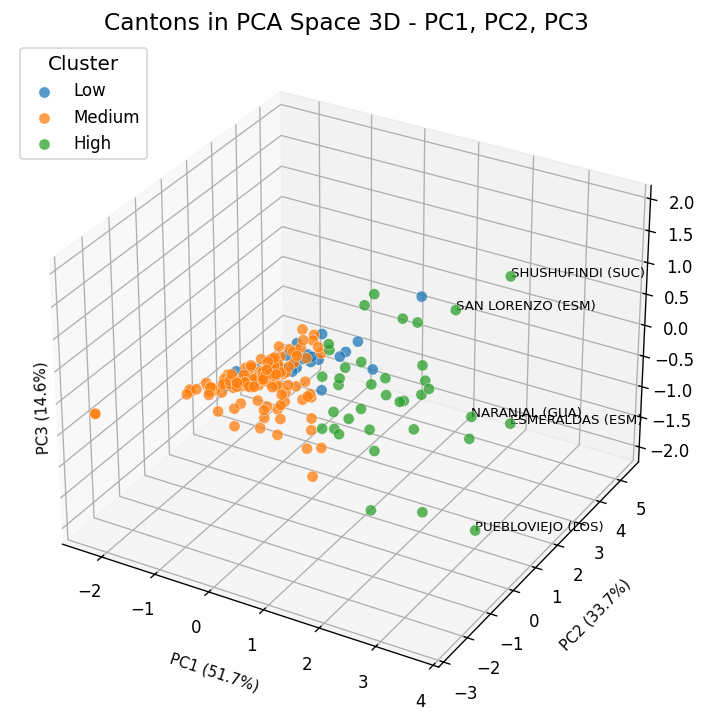

In [38]:

# ── 3D: PC1, PC2, PC3 ─────────────────────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 6))
ax  = fig.add_subplot(111, projection='3d') #, elev=20, azim=-135)

for lbl in CLUSTER_ORDER:
    sub = pc_canton[pc_canton['cluster_label'] == lbl]
    ax.scatter(sub['pc1'], sub['pc2'], sub['pc3'],
               label=lbl, color=CLUSTER_COLOR_MAP[lbl],
               alpha=0.75, s=45, edgecolors='white', linewidths=0.3)

for _, row in pc_canton.nlargest(5, 'indice_riesgo').iterrows():
    short_prov = str(row['provincia_key'])[:3]
    ax.text(row['pc1'], row['pc2'], row['pc3'],
            f"{row['canton_key']} ({short_prov})", fontsize=8)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=9, labelpad=8)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=9, labelpad=8)
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})", fontsize=9, labelpad=-235)
# Rotate z label
ax.zaxis.set_rotate_label(False)
ax.zaxis.label.set_rotation(92)
ax.set_title('Cantons in PCA Space 3D - PC1, PC2, PC3', fontsize=14)
ax.legend(title='Cluster', fontsize=10, title_fontsize=12, loc='upper left')
# tight_layout no funciona con Axes3D; se ajustan márgenes manualmente
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.95)
plt.savefig('plots/kmeans_clusters_3d_pca.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Analysis and Visualizations

### 5a. Index Distribution by Cluster

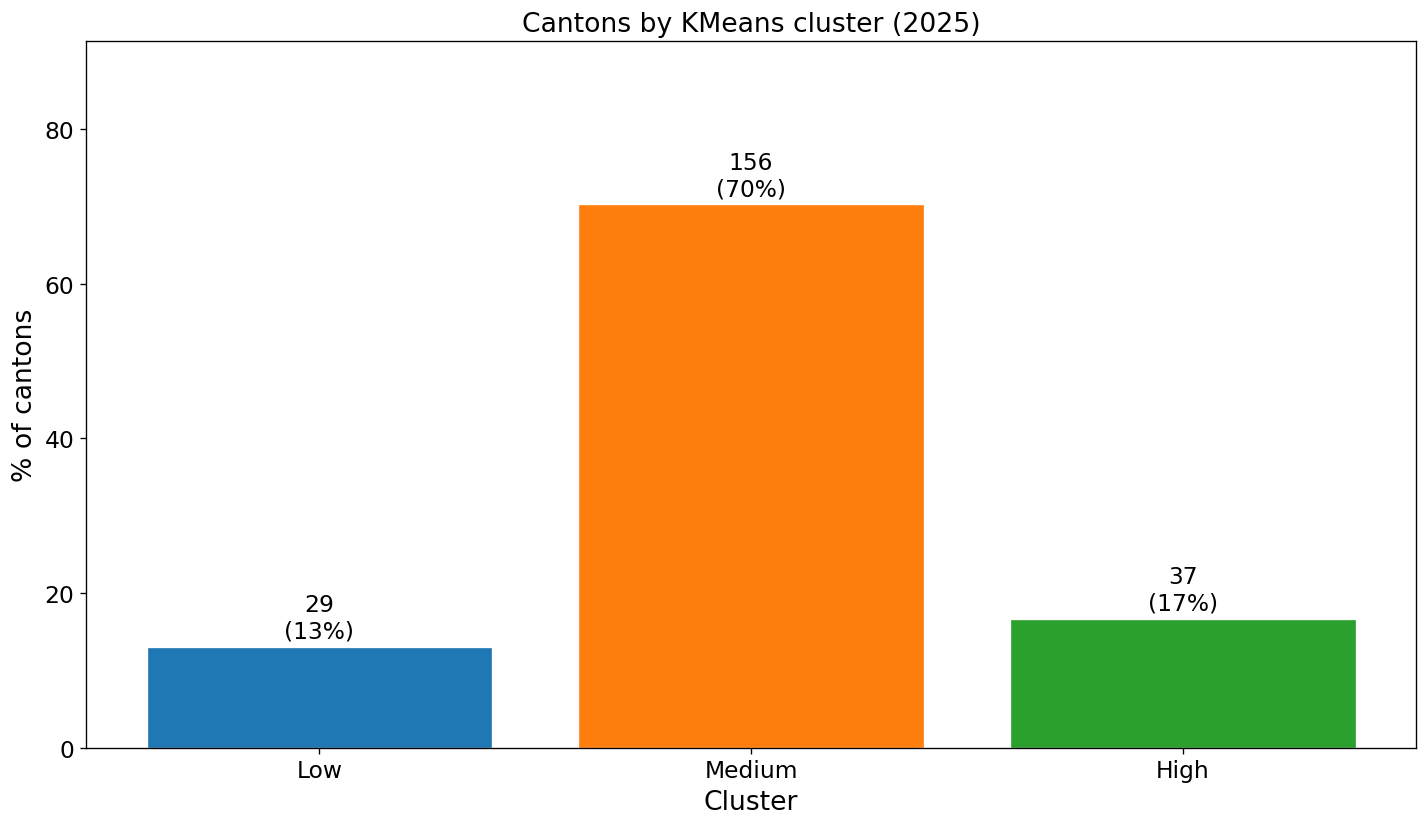

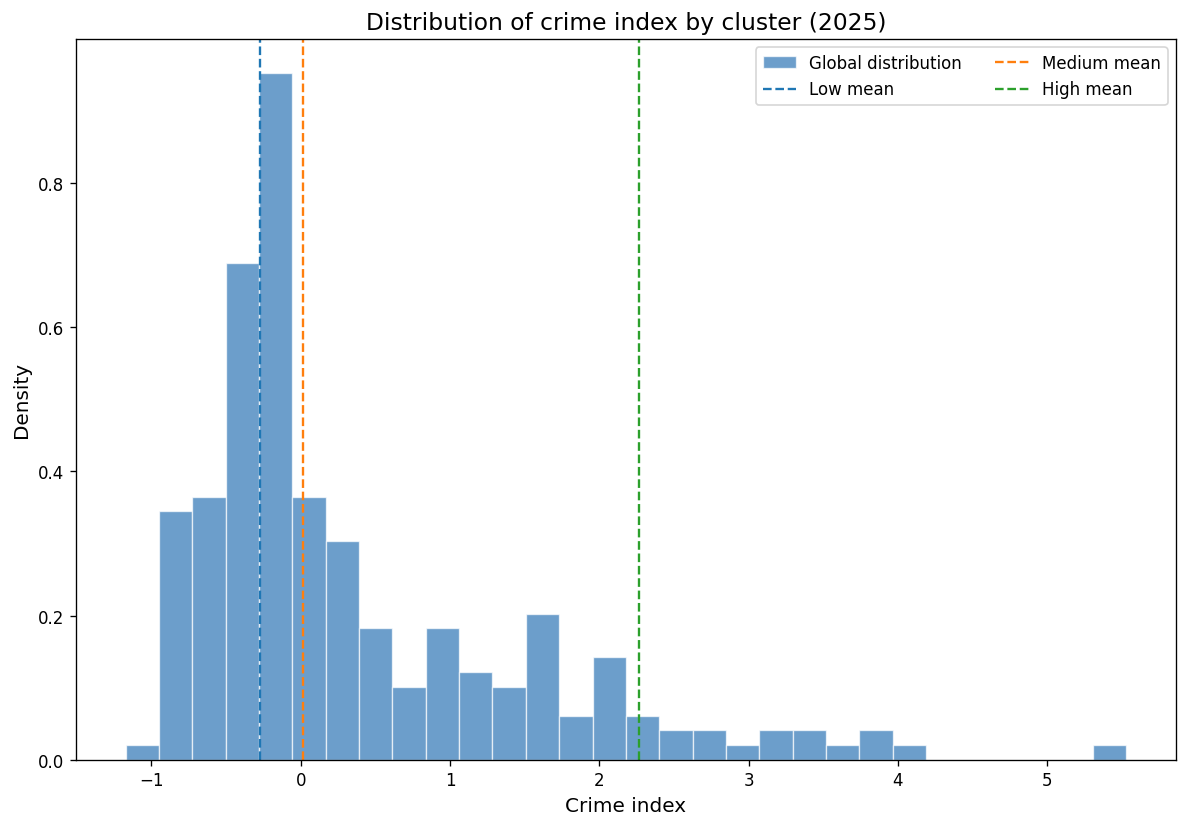

In [39]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['figure.dpi'] = 120
os.makedirs('plots', exist_ok=True)

ANIO_REF = 2025
df_ref   = master_annual[master_annual['anio'] == ANIO_REF].copy()

# ── Plot 1: % of cantons per KMeans cluster ───────────────────────────────
plt.figure(figsize=(12, 7))
counts = df_ref['cluster_label'].value_counts().reindex(CLUSTER_ORDER, fill_value=0)
pcts   = counts / counts.sum() * 100
cluster_colors = [CLUSTER_COLOR_MAP[c] for c in counts.index]
bars = plt.bar(counts.index, pcts.values,
               color=cluster_colors, edgecolor='white', linewidth=0.8)
for bar, p, n in zip(bars, pcts, counts):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{n}\n({p:.0f}%)', ha='center', va='bottom', fontsize=14)
plt.title(f'Cantons by KMeans cluster ({ANIO_REF})', fontsize=16)
plt.xlabel('Cluster', fontsize=16)
plt.ylabel('% of cantons', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, pcts.max() * 1.30)
plt.tight_layout()
plt.savefig('plots/cantones_por_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Index distribution + mean per cluster ─────────────────────────
plt.figure(figsize=(10, 7))
plt.hist(df_ref['indice_riesgo'], bins=30, density=True,
         color='#2E75B6', edgecolor='white', linewidth=0.8, alpha=0.7,
         label='Global distribution')

for lbl in CLUSTER_ORDER:
    sub = df_ref[df_ref['cluster_label'] == lbl]
    if len(sub) == 0:
        continue
    c = sub['indice_riesgo'].mean()
    plt.axvline(c, color=CLUSTER_COLOR_MAP[lbl], linestyle='--', linewidth=1.4,
                label=f'{lbl} mean')

plt.title(f'Distribution of crime index by cluster ({ANIO_REF})', fontsize=14)
plt.xlabel('Crime index', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.savefig('plots/distribucion_riesgo_por_cluster.png', dpi=150, bbox_inches='tight')
plt.show()


### 5b. Correlations Between Indicators

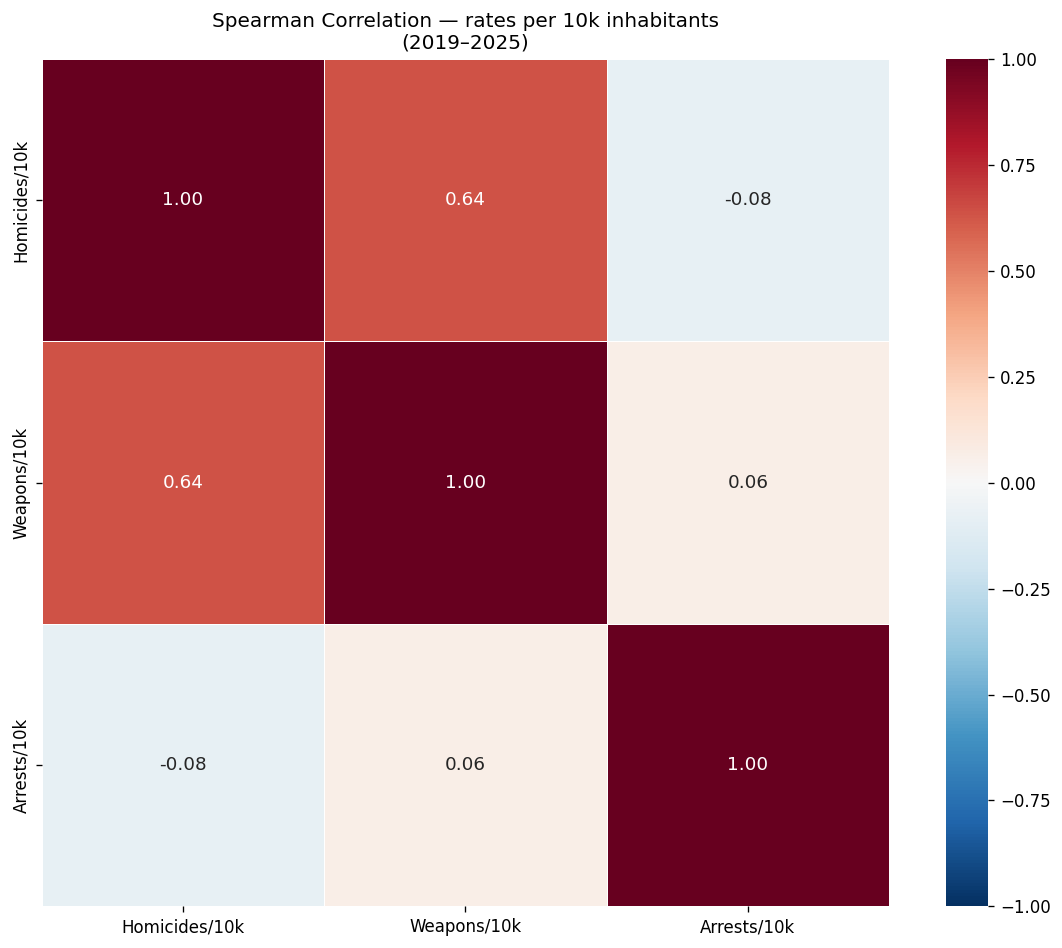

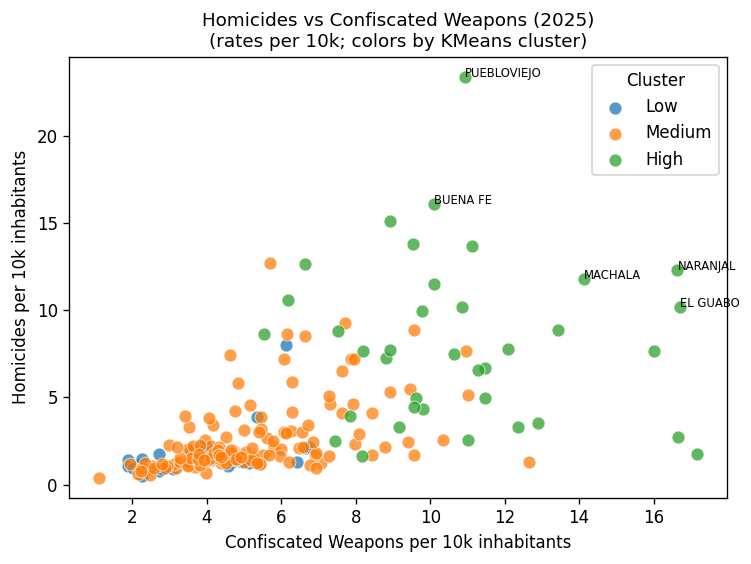


Spearman correlation with the crime index (rates per 10k):
  Homicides/10k         : r = 0.789
  Weapons/10k           : r = 0.952
  Arrests/10k           : r = 0.095


In [40]:
plt.figure(figsize=(10, 8))

# ── Spearman heatmap on rates per 10k ────────────────────────────────────
corr = master_annual[RATES].corr(method='spearman')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, annot_kws={'size': 11},
            xticklabels=RATES_LABELS,
            yticklabels=RATES_LABELS)
plt.title('Spearman Correlation — rates per 10k inhabitants\n(2019–2025)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/correlacion_tasas.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Scatter: homicides vs weapons, colored by KMeans cluster ──────────────
for lbl in CLUSTER_ORDER:
    sub = df_ref[df_ref['cluster_label'] == lbl]
    plt.scatter(sub['armas_incautadas_r1k'], sub['homicidios_r1k'],
                label=lbl, color=CLUSTER_COLOR_MAP[lbl],
                alpha=0.75, s=60, edgecolors='white', linewidths=0.5)
for _, row in df_ref.nlargest(5, 'indice_riesgo').iterrows():
    plt.annotate(row['canton_key'],
                 (row['armas_incautadas_r1k'], row['homicidios_r1k']),
                 fontsize=7)
plt.xlabel('Confiscated Weapons per 10k inhabitants')
plt.ylabel('Homicides per 10k inhabitants')
plt.title(f'Homicides vs Confiscated Weapons ({ANIO_REF})\n'
          '(rates per 10k; colors by KMeans cluster)', fontsize=11)
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('plots/homicidios_vs_armas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSpearman correlation with the crime index (rates per 10k):")
for col, lbl in zip(RATES, RATES_LABELS):
    r = master_annual[col].corr(master_annual['indice_riesgo'], method='spearman')
    print(f"  {lbl:<22}: r = {r:.3f}")


### 5c. Temporal Evolution (Monthly Granularity)

The monthly dataset reveals patterns hidden by annual analysis: seasonal peaks, sudden escalations, and smoothed trends. The full homicide series (2014–2025) is used; 2026 is excluded as it is an incomplete year.

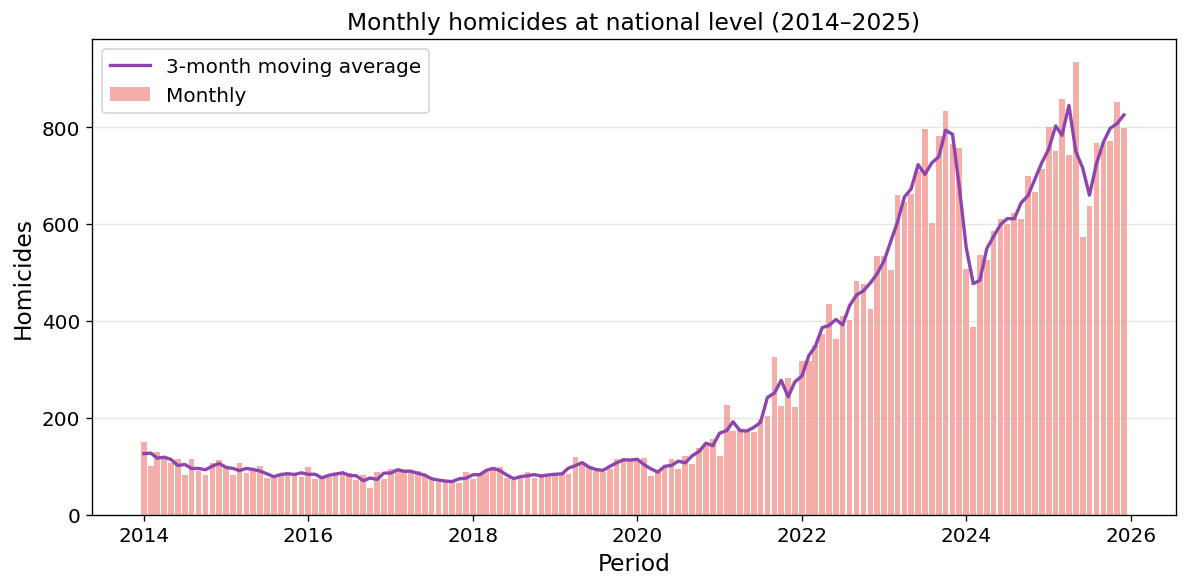

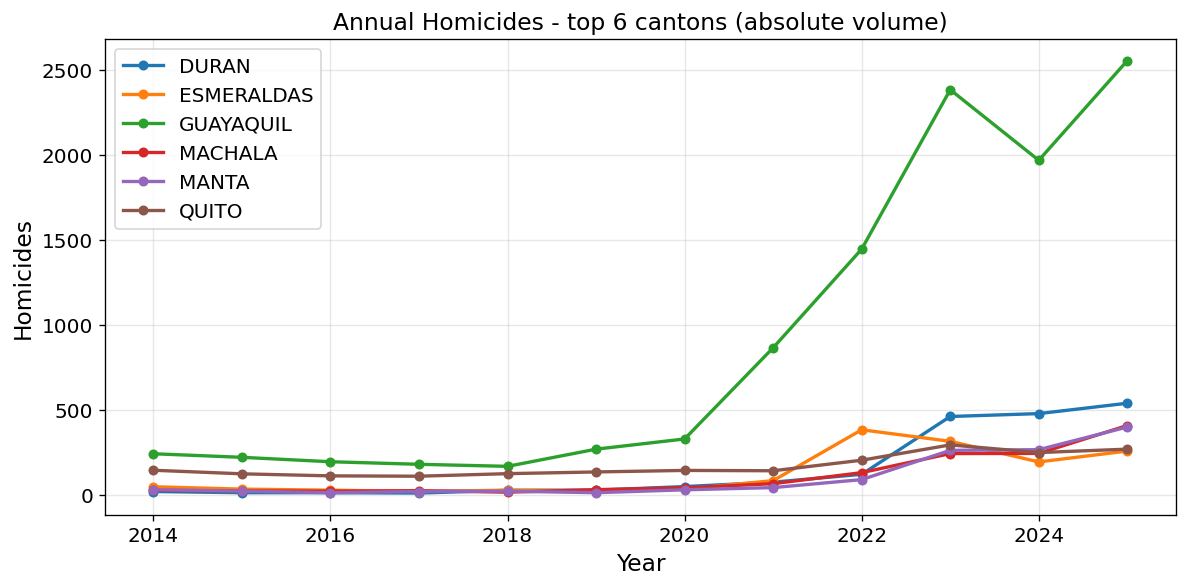

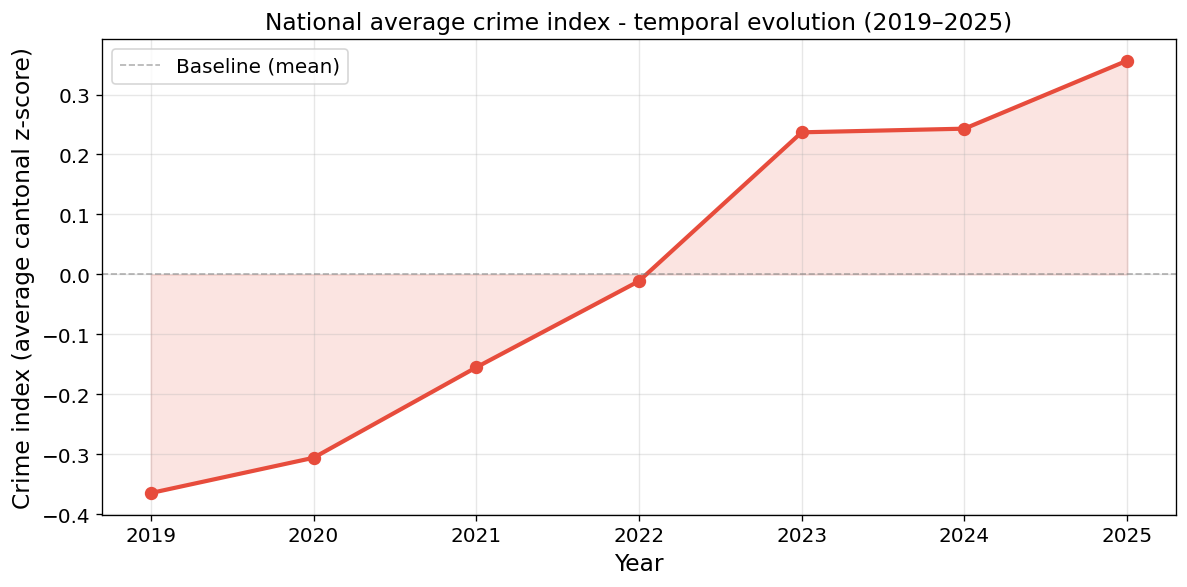

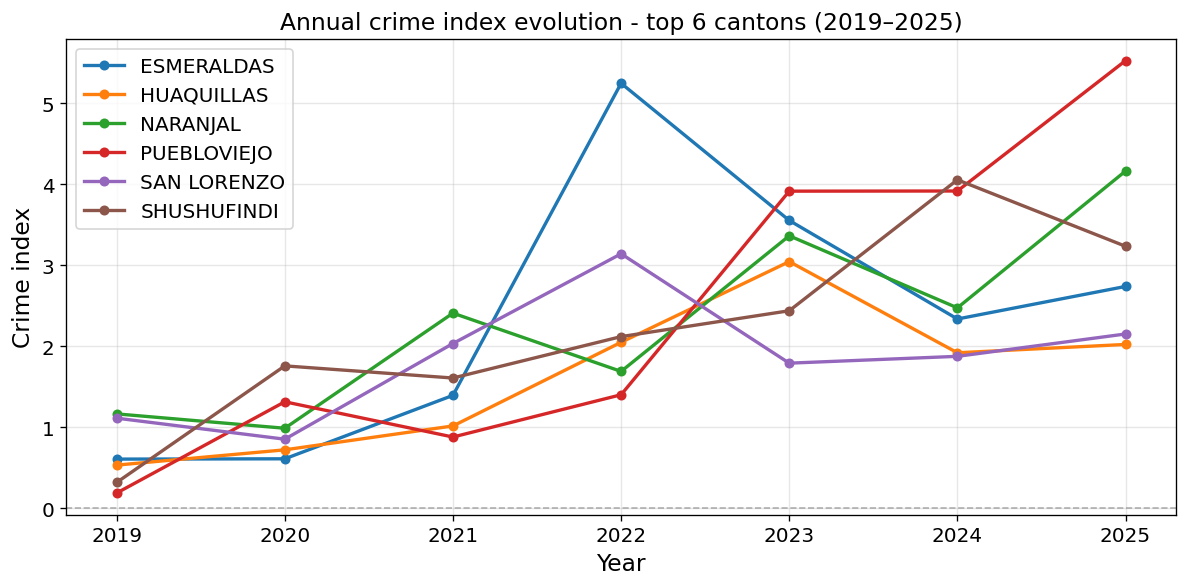

In [41]:
MESES_LBL = ['Ene','Feb','Mar','Abr','May','Jun',
             'Jul','Ago','Sep','Oct','Nov','Dic']

# ── Dataset mensual 2014-2025 ──────────────────────────────────────────────
master_ts = master[master['anio'].isin(range(2014, 2026))].copy()
master_ts['anio'] = master_ts['anio'].astype(int)
master_ts['mes']  = master_ts['mes'].astype(int)
master_ts['periodo'] = pd.to_datetime(
    master_ts['anio'].astype(str) + '-' +
    master_ts['mes'].astype(str).str.zfill(2) + '-01'
)

# ── Plot 1: Serie mensual nacional — barras + media móvil 3m ──────────────
plt.figure(figsize=(10, 5))
nac_mens = (master_ts.groupby('periodo')['homicidios']
            .sum().reset_index().sort_values('periodo'))
roll3 = nac_mens['homicidios'].rolling(3, center=True, min_periods=2).mean()

plt.bar(nac_mens['periodo'], nac_mens['homicidios'],
        color='#E74C3C', alpha=0.45, width=25, label='Monthly')
plt.plot(nac_mens['periodo'], roll3, color='#8e44ad',
         linewidth=2, label='3-month moving average')
plt.title('Monthly homicides at national level (2014–2025)', fontsize=14)
plt.xlabel('Period', fontsize=14)
plt.ylabel('Homicides', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/homicidios_mensuales.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Annual homicides evolution — top 6 cantons ───────────────────
plt.figure(figsize=(10, 5))
top_cant = (master_ts.groupby('canton_key')['homicidios']
            .sum().nlargest(6).index.tolist())
df_top_ann = (master_ts[master_ts['canton_key'].isin(top_cant)]
              .groupby(['anio', 'canton_key'])['homicidios'].sum().reset_index())
for canton, grp in df_top_ann.groupby('canton_key'):
    plt.plot(grp['anio'], grp['homicidios'], marker='o',
             linewidth=2, label=canton, markersize=5)
plt.title('Annual Homicides - top 6 cantons (absolute volume)', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Homicides', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/homicidios_top_cantones.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: National average risk index by year ─────────────────────────────
plt.figure(figsize=(10, 5))
idx_nac = (master_annual.groupby('anio')['indice_riesgo']
           .mean().reset_index().sort_values('anio'))
idx_nac['anio'] = idx_nac['anio'].astype(int)
plt.plot(idx_nac['anio'], idx_nac['indice_riesgo'],
         marker='o', color='#E74C3C', linewidth=2.5, markersize=7)
plt.fill_between(idx_nac['anio'], idx_nac['indice_riesgo'],
                 alpha=0.15, color='#E74C3C')
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Baseline (mean)')
plt.title('National average crime index - temporal evolution (2019–2025)', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Crime index (average cantonal z-score)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/indice_riesgo_nacional.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 4: Annual crime index evolution — top 6 cantons by index ─────────
plt.figure(figsize=(10, 5))
top_cant_idx = (master_annual.groupby('canton_key')['indice_riesgo']
                .mean().nlargest(6).index.tolist())
df_idx_top = (master_annual[master_annual['canton_key'].isin(top_cant_idx)]
              [['anio', 'canton_key', 'indice_riesgo']].copy())
df_idx_top['anio'] = df_idx_top['anio'].astype(int)

palette_idx = [plt.cm.tab10.colors[i] for i in range(6)]
for (canton, grp), color in zip(df_idx_top.groupby('canton_key'), palette_idx):
    plt.plot(grp.sort_values('anio')['anio'],
             grp.sort_values('anio')['indice_riesgo'],
             marker='o', linewidth=2, label=canton, markersize=5, color=color)
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
plt.title('Annual crime index evolution - top 6 cantons (2019–2025)', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Crime index', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/indice_riesgo_top_cantones.png', dpi=150, bbox_inches='tight')
plt.show()


### 5d. Canton Profiles: Outliers and Risk Rankings

In [42]:
COLS_SHOW = ['canton_key', 'provincia_key', 'anio',
             'homicidios', 'armas_incautadas', 'arrestos',
             'homicidios_r1k', 'armas_incautadas_r1k', 'arrestos_r1k',
             'indice_riesgo', 'cluster_label']

pd.set_option('display.float_format', '{:.2f}'.format)

top10 = df_ref.nlargest(10, 'indice_riesgo')[COLS_SHOW].reset_index(drop=True)
bot10 = df_ref.nsmallest(10, 'indice_riesgo')[COLS_SHOW].reset_index(drop=True)

print(f"═══ Top 10 cantons by highest crime index — {ANIO_REF} ═══")
print(top10.to_string(index=False))
print(f"\n═══ 10 cantons by lowest crime index — {ANIO_REF} ═══")
print(bot10.to_string(index=False))


═══ Top 10 cantons by highest crime index — 2025 ═══
 canton_key provincia_key  anio  homicidios  armas_incautadas  arrestos  homicidios_r1k  armas_incautadas_r1k  arrestos_r1k  indice_riesgo cluster_label
PUEBLOVIEJO      LOS RIOS  2025      165.00             66.00    175.00           23.37                 10.94         40.18           5.53          High
   NARANJAL        GUAYAS  2025      142.00            186.00    308.00           12.28                 16.64         35.47           4.16          High
   BUENA FE      LOS RIOS  2025      173.00             98.00    348.00           16.11                 10.09         42.07           3.83          High
   EL GUABO        EL ORO  2025       87.00            138.00    425.00           10.17                 16.70         59.76           3.81          High
    MACHALA        EL ORO  2025      408.00            482.00   1758.00           11.77                 14.12         53.43           3.67          High
   BABAHOYO      LOS RIOS  20

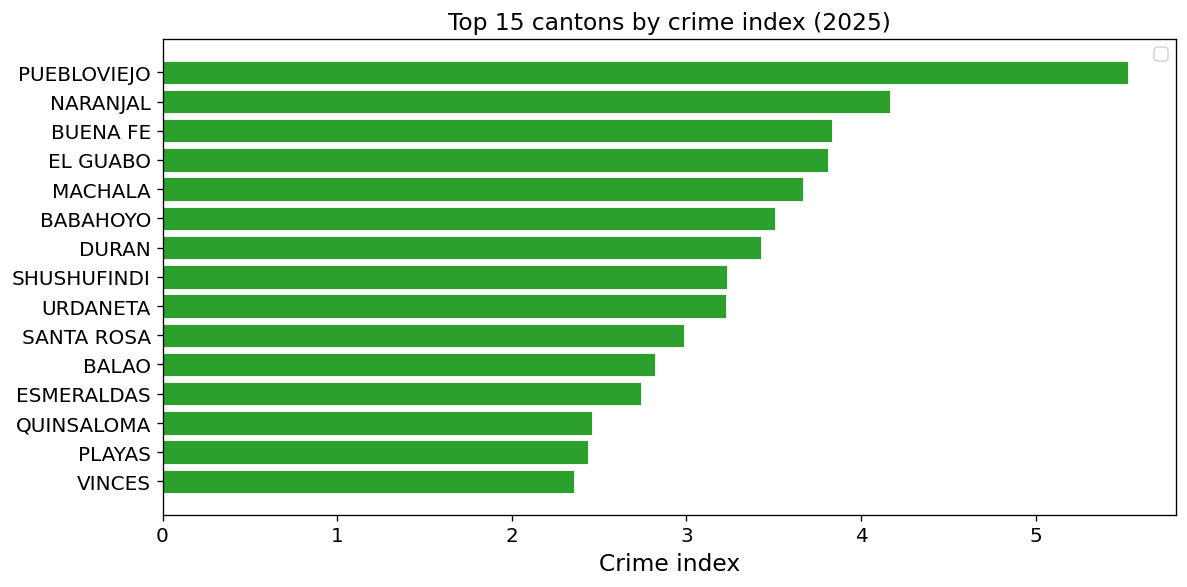

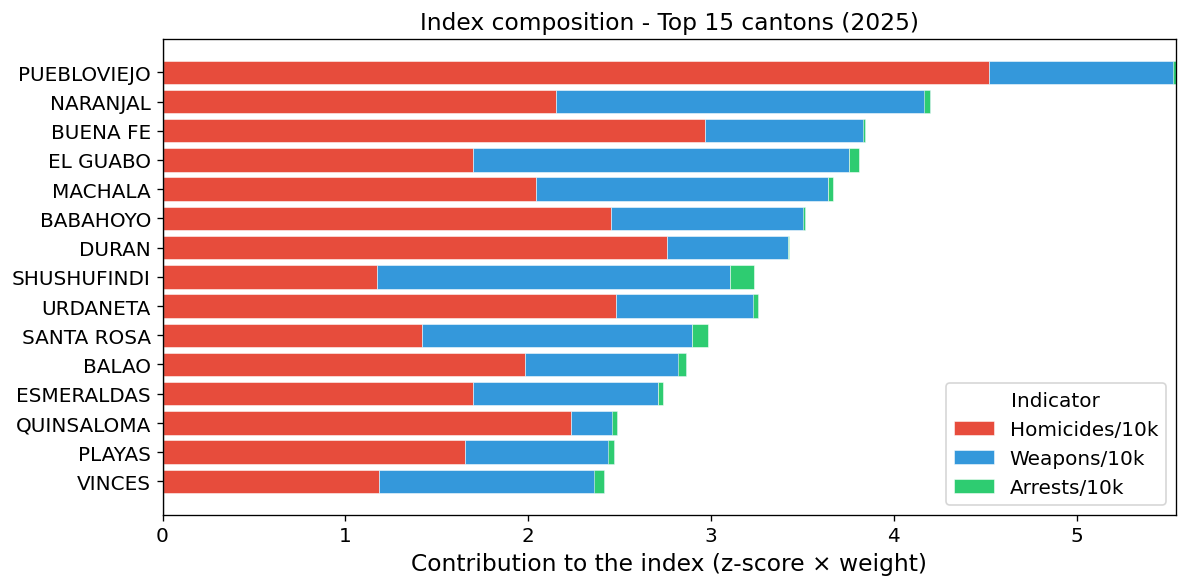

In [43]:
# ── Top 15 cantones por índice de riesgo (año referencia) ────────────────
top15 = df_ref.nlargest(15, 'indice_riesgo').sort_values('indice_riesgo')

plt.figure(figsize=(10, 5))

# — Barras horizontales: índice z-score, coloreado por cluster ─────────────
bar_colors = [CLUSTER_COLOR_MAP[n] for n in top15['cluster_label']]
plt.barh(top15['canton_key'], top15['indice_riesgo'],
         color=bar_colors, edgecolor='white', linewidth=0.5)
plt.xlabel('Crime index', fontsize=14)
plt.title(f'Top 15 cantons by crime index ({ANIO_REF})', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plots/top15_cantones_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()

# — Stacked bar: contribución de cada indicador (z×peso) ─────────────────
plt.figure(figsize=(10, 5))
top15 = df_ref.nlargest(15, 'indice_riesgo').sort_values('indice_riesgo')
bottom = np.zeros(len(top15))
bar_palette = ['#E74C3C', '#3498DB', '#2ECC71']
for z_col, lbl, color, peso in zip(Z_COLS, RATES_LABELS, bar_palette, PESOS):
    vals = (top15[z_col] * peso).values
    plt.barh(top15['canton_key'], vals, left=bottom,
             label=lbl, color=color, edgecolor='white', linewidth=0.3)
    bottom += vals
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel('Contribution to the index (z-score × weight)', fontsize=14)
plt.title(f'Index composition - Top 15 cantons ({ANIO_REF})', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Indicator', loc='lower right', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.savefig('plots/perfiles_canton.png', dpi=150, bbox_inches='tight')
plt.show()

### Diagnostic: Per Capita Ranking vs. Absolute Volume

The index measures **risk per resident**, not total crime. Large cantons like Quito or Guayaquil have a lot of crime in absolute terms, but when divided by their large population their **rate per 10k** falls below the national mean — which is pulled upward by small cantons with high concentration.

A negative z-score **does not mean "safe"**: it means the per capita risk is below the average across all Ecuadorian cantons, which includes many small rural cantons with extremely high rates. The visualizations below show both dimensions.

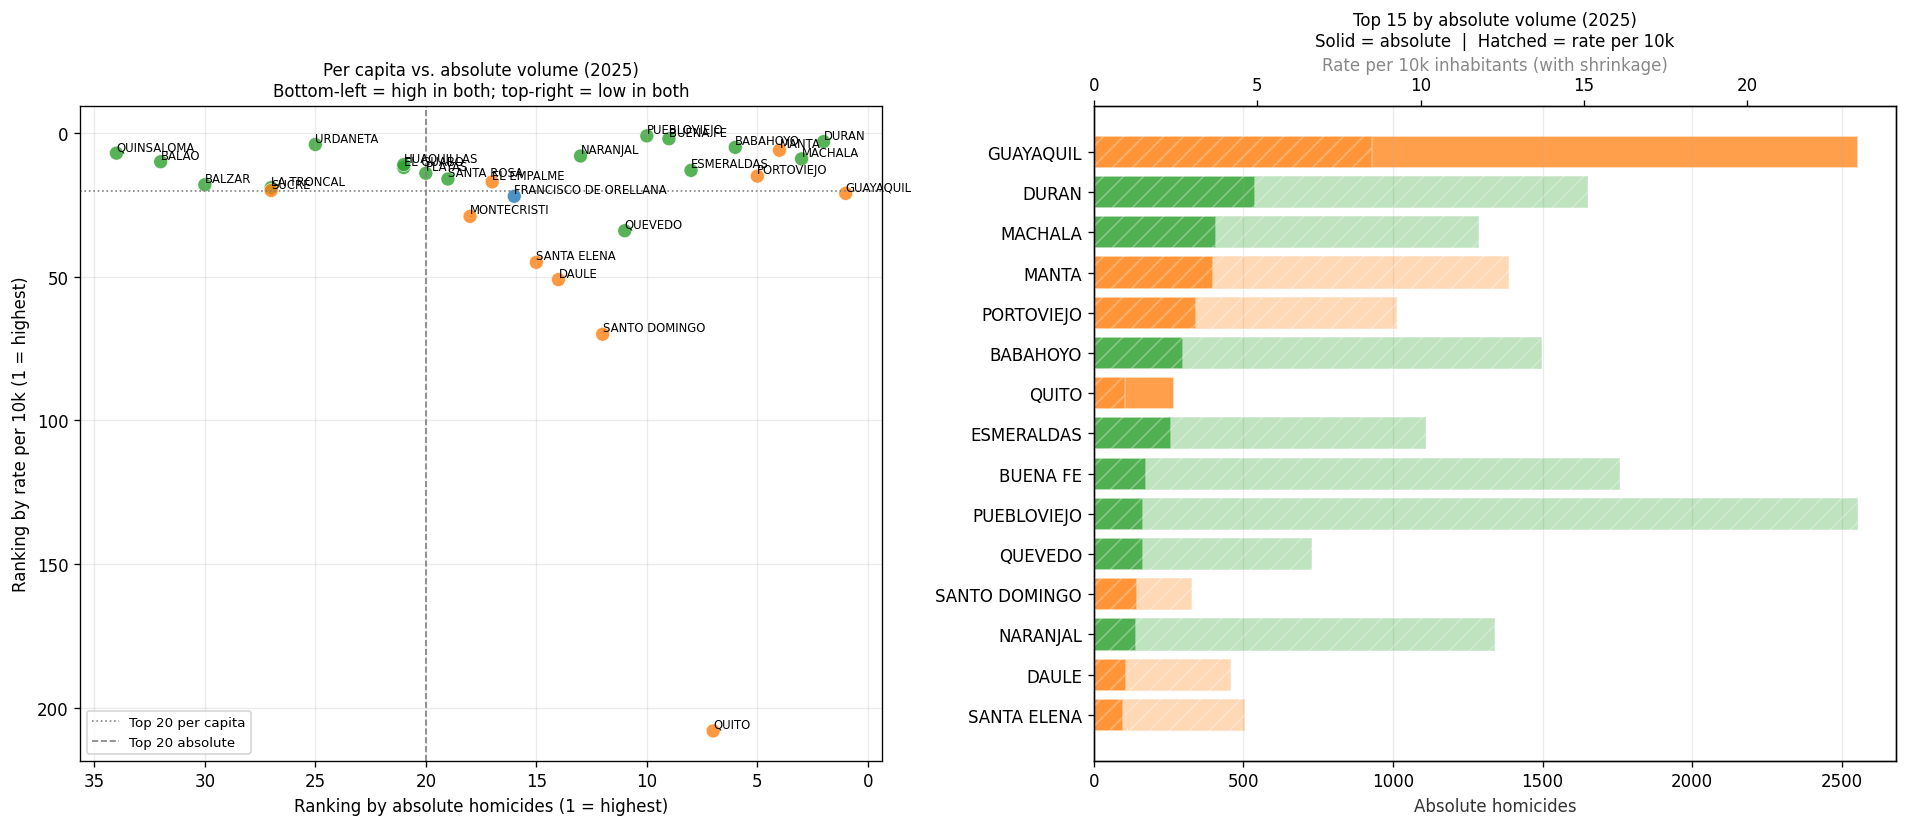

Key cantons — dual ranking (2025):
canton_key  poblacion  homicidios  homicidios_r1k  indice_riesgo  rank_absoluto  rank_percapita cluster_label
 GUAYAQUIL 2982756.00     2553.00            8.50           1.56              1              21        Medium
     DURAN  332968.00      539.00           15.12           3.43              2               3          High
   MACHALA  324062.00      408.00           11.77           3.67              3               9          High
     MANTA  291322.00      399.00           12.70           2.31              4               6        Medium
     QUITO 2856667.00      269.00            0.95          -0.83              7             208        Medium
ESMERALDAS  232221.00      258.00           10.16           2.74              8              13          High

→ A negative z-score in 'indice_riesgo' means the canton's per capita rate is
  BELOW the cantonal mean, which includes many small cantons with extreme rates.
  It does not imply the canton is s

In [44]:
# ── Per capita vs. absolute ranking for homicides (reference year) ────────
N = 20
df_dual = df_ref[['canton_key', 'provincia_key', 'poblacion',
                   'homicidios', 'homicidios_r1k', 'indice_riesgo', 'cluster_label']].copy()

# Drop rows without population data
df_dual = df_dual.dropna(subset=['homicidios_r1k'])

df_dual['rank_percapita'] = df_dual['homicidios_r1k'].rank(ascending=False, method='min').astype('Int64')
df_dual['rank_absoluto']  = df_dual['homicidios'].rank(ascending=False, method='min').astype('Int64')

# Cantons of interest: top N per capita ∪ top N absolute ∪ major cities
top_pc  = set(df_dual.nsmallest(N, 'rank_percapita')['canton_key'])
top_abs = set(df_dual.nsmallest(N, 'rank_absoluto')['canton_key'])
focus   = top_pc | top_abs | {'QUITO', 'GUAYAQUIL'}
df_focus = df_dual[df_dual['canton_key'].isin(focus)].copy()

# ── Scatter: per capita rank vs absolute rank ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cluster_col = [CLUSTER_COLOR_MAP.get(c, 'gray') for c in df_focus['cluster_label']]
axes[0].scatter(df_focus['rank_absoluto'].astype(float),
                df_focus['rank_percapita'].astype(float),
                c=cluster_col, s=70, alpha=0.8, edgecolors='white', linewidths=0.4)
for _, row in df_focus.iterrows():
    if row['rank_percapita'] <= N or row['rank_absoluto'] <= N or row['canton_key'] in ('QUITO', 'GUAYAQUIL'):
        axes[0].annotate(
            row['canton_key'],
            (float(row['rank_absoluto']), float(row['rank_percapita'])),
            fontsize=7, ha='left', va='bottom'
        )
axes[0].axhline(N, color='gray', linestyle=':', linewidth=1, label=f'Top {N} per capita')
axes[0].axvline(N, color='gray', linestyle='--', linewidth=1, label=f'Top {N} absolute')
axes[0].set_xlabel('Ranking by absolute homicides (1 = highest)')
axes[0].set_ylabel('Ranking by rate per 10k (1 = highest)')
axes[0].set_title(f'Per capita vs. absolute volume ({ANIO_REF})\n'
                  'Bottom-left = high in both; top-right = low in both', fontsize=10)
axes[0].invert_xaxis(); axes[0].invert_yaxis()
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

# ── Dual bar chart: top 15 by absolute count ─────────────────────────────
top15_abs = df_dual.nsmallest(15, 'rank_absoluto').sort_values('homicidios')
bar_c = [CLUSTER_COLOR_MAP.get(c, 'gray') for c in top15_abs['cluster_label']]
ax2 = axes[1].twiny()
axes[1].barh(top15_abs['canton_key'], top15_abs['homicidios'],
             color=bar_c, alpha=0.75, edgecolor='white', label='Absolute homicides')
ax2.barh(top15_abs['canton_key'], top15_abs['homicidios_r1k'],
          color=bar_c, alpha=0.30, hatch='//', edgecolor='white', label='Rate per 10k (top axis)')
axes[1].set_xlabel('Absolute homicides', color='#333')
ax2.set_xlabel('Rate per 10k inhabitants (with shrinkage)', color='#888')
axes[1].set_title(f'Top 15 by absolute volume ({ANIO_REF})\n'
                  'Solid = absolute  |  Hatched = rate per 10k', fontsize=10)
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.savefig('plots/ranking_percapita_vs_absoluto.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Comparison table for key cities ──────────────────────────────────────
clave = ['QUITO', 'GUAYAQUIL', 'MANTA', 'MACHALA', 'DURAN', 'ESMERALDAS']
df_tabla = (
    df_dual[df_dual['canton_key'].isin(clave)]
    .sort_values('rank_absoluto')
    [['canton_key', 'poblacion', 'homicidios', 'homicidios_r1k',
      'indice_riesgo', 'rank_absoluto', 'rank_percapita', 'cluster_label']]
)
pd.set_option('display.float_format', '{:.2f}'.format)
print(f"Key cantons — dual ranking ({ANIO_REF}):")
print(df_tabla.to_string(index=False))
print()
print("→ A negative z-score in 'indice_riesgo' means the canton's per capita rate is")
print("  BELOW the cantonal mean, which includes many small cantons with extreme rates.")
print("  It does not imply the canton is safe in absolute terms.")
